# Image Enhancement: Power-Law (Gamma) Transformation

This notebook introduces **power-law transformation**, commonly called **gamma correction**. It is a point operation used to adjust image brightness in a controlled way.

## Learning Objectives

After completing this notebook, students should be able to:

1. Explain the power-law transformation formula.
2. Describe the effect of different gamma values.
3. Read an image safely with OpenCV.
4. Apply gamma correction using NumPy.
5. Compare vectorized processing, pixel-by-pixel loops, and lookup tables.
6. Save an enhanced image correctly.

## 1. Power-Law Transformation

The power-law transformation is defined as:

$$
s = c r^\gamma
$$

where:

- $r$ is the input pixel intensity.
- $s$ is the output pixel intensity.
- $c$ is a scaling constant.
- $\gamma$ is the gamma value.

For an 8-bit image, pixel values are usually normalized from `[0, 255]` to `[0, 1]`, transformed, and then scaled back to `[0, 255]`:

$$
s = 255 \left(\frac{r}{255}\right)^\gamma
$$

## 2. Effect of Gamma Values

Gamma controls how brightness changes:

1. `gamma < 1` makes the image brighter.
2. `gamma = 1` keeps the image unchanged.
3. `gamma > 1` makes the image darker.

This transformation is useful when an image is too dark, too bright, or needs better visual contrast for observation.

## 3. Import Libraries and Define Helper Functions

OpenCV returns `None` when `cv2.imread()` cannot load an image. This can happen when the file path is wrong or the file does not exist.

Always check the loaded image before using it.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = Path("images")
OUT_DIR = Path("outs")
OUT_DIR.mkdir(exist_ok=True)


def read_image(fp, flags=cv2.IMREAD_GRAYSCALE):
    img = cv2.imread(str(fp), flags)

    if img is None:
        raise FileNotFoundError(f"Image file not found: {fp}")

    return img


def gamma_transform(img, gamma):
    img_float = img.astype(np.float32) / 255.0
    corrected = 255.0 * (img_float ** gamma)
    return np.clip(corrected, 0, 255).astype(np.uint8)


def show_gray_pair(original, transformed, title1="Original", title2="Enhanced"):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title1)
    axes[0].axis("off")

    axes[1].imshow(transformed, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(title2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## 4. Read a Grayscale Image

The image `dark2.png` is used because gamma correction is easy to observe on a dark image.

type: <class 'numpy.ndarray'>
shape: (700, 700)
dtype: uint8
min, max: 2 50


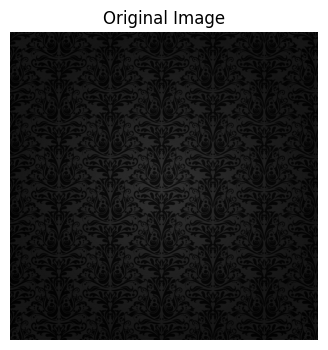

In [2]:
fp = IMAGE_DIR / "dark2.png"
img = read_image(fp, cv2.IMREAD_GRAYSCALE)

print("type:", type(img))
print("shape:", img.shape)
print("dtype:", img.dtype)
print("min, max:", img.min(), img.max())

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")
plt.show()

## 5. Method I: Vectorized NumPy Operation

This is the recommended method for practical use. NumPy applies the formula to every pixel at once, so the code is short and efficient.

In this example, `gamma = 0.5`, so the image becomes brighter.

gamma: 0.5
original shape: (700, 700)
enhanced shape: (700, 700)
dtype: uint8


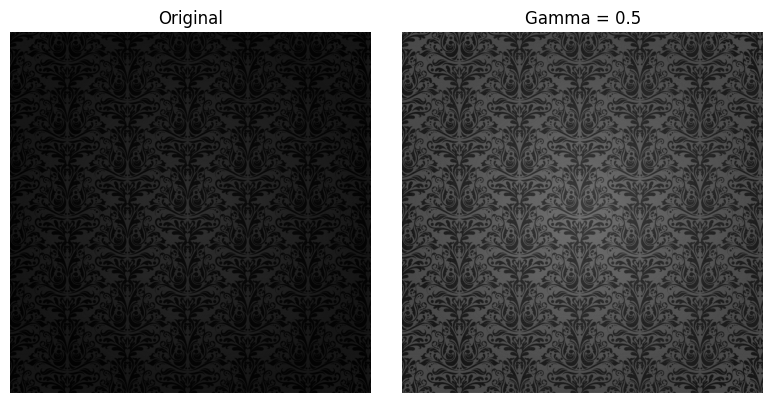

In [3]:
gamma = 0.5
gamma_img = gamma_transform(img, gamma)

print("gamma:", gamma)
print("original shape:", img.shape)
print("enhanced shape:", gamma_img.shape)
print("dtype:", gamma_img.dtype)

show_gray_pair(img, gamma_img, title2=f"Gamma = {gamma}")

## 6. Compare Several Gamma Values

The best gamma value depends on the image and the purpose of enhancement. Viewing several values side by side helps students understand the effect of gamma.

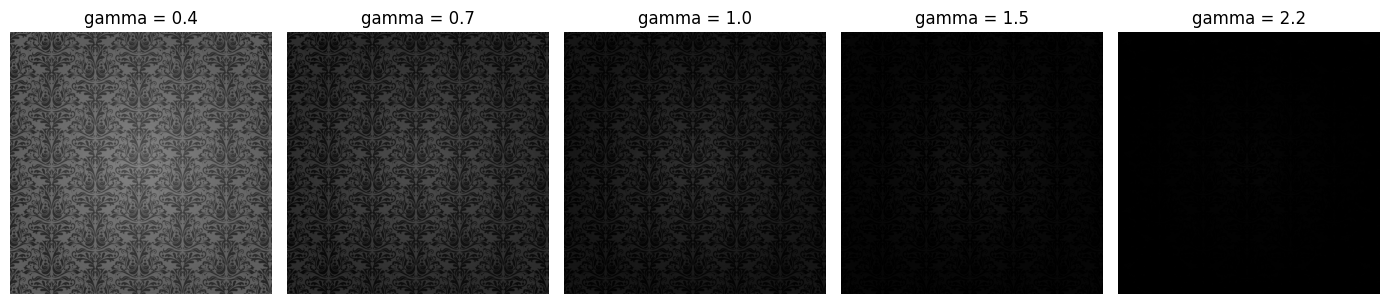

In [4]:
gamma_values = [0.4, 0.7, 1.0, 1.5, 2.2]

fig, axes = plt.subplots(1, len(gamma_values), figsize=(14, 3))

for ax, gamma_value in zip(axes, gamma_values):
    result = gamma_transform(img, gamma_value)
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"gamma = {gamma_value}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Save the Enhanced Image

`cv2.imwrite()` returns `True` if the image was saved successfully. Checking this value helps detect save errors early.

In [5]:
out_fp = OUT_DIR / "dark2_gamma_0_5.png"
saved = cv2.imwrite(str(out_fp), gamma_img)

if not saved:
    raise IOError(f"Could not save image: {out_fp}")

print(f"Saved image: {out_fp}")

Saved image: outs\dark2_gamma_0_5.png


## 8. Method II: Pixel-by-Pixel Loop

This method is useful for teaching the idea behind the formula. However, it is slower and longer than the vectorized NumPy method.

Loop result equals vectorized result: True


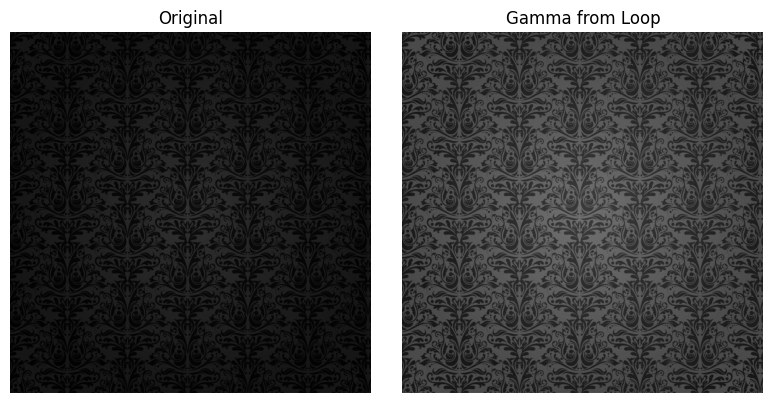

In [6]:
gamma_loop = np.zeros_like(img, dtype=np.uint8)
rows, cols = img.shape

for y in range(rows):
    for x in range(cols):
        r = img[y, x] / 255.0
        gamma_loop[y, x] = np.clip(255.0 * (r ** gamma), 0, 255)

print("Loop result equals vectorized result:", np.array_equal(gamma_loop, gamma_img))
show_gray_pair(img, gamma_loop, title2="Gamma from Loop")

## 9. Method III: Lookup Table

A lookup table stores the transformed value for every possible input intensity from `0` to `255`. OpenCV can then apply the table quickly with `cv2.LUT()`.

This method is efficient for 8-bit images because there are only 256 possible input values.

LUT result equals vectorized result: True


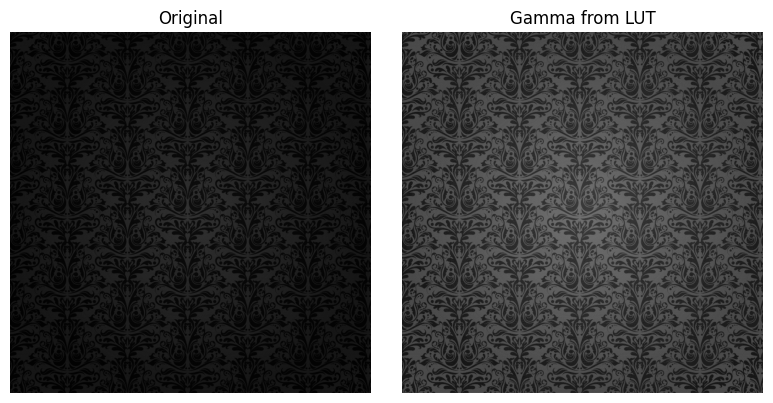

In [7]:
table = np.array([
    np.clip(255.0 * ((i / 255.0) ** gamma), 0, 255)
    for i in range(256)
], dtype=np.uint8)

gamma_lut = cv2.LUT(img, table)

print("LUT result equals vectorized result:", np.array_equal(gamma_lut, gamma_img))
show_gray_pair(img, gamma_lut, title2="Gamma from LUT")

## 10. Inspect Pixel Values

The following code prints a few sample pixel values before and after gamma correction. This makes the transformation easier to understand numerically.

In [8]:
sample_points = [
    (0, 0),
    (img.shape[0] // 2, img.shape[1] // 2),
    (img.shape[0] - 1, img.shape[1] - 1),
]

for y, x in sample_points:
    original_value = img[y, x]
    enhanced_value = gamma_img[y, x]
    print(f"Position ({y:3d}, {x:3d}) : {original_value:3d} -> {enhanced_value:3d}")

Position (  0,   0) :  21 ->  73
Position (350, 350) :  13 ->  57
Position (699, 699) :   8 ->  45


## 11. Plot the Transformation Curves

The curve shows how each input intensity is mapped to an output intensity.

- A curve above the diagonal line makes pixels brighter.
- A curve below the diagonal line makes pixels darker.

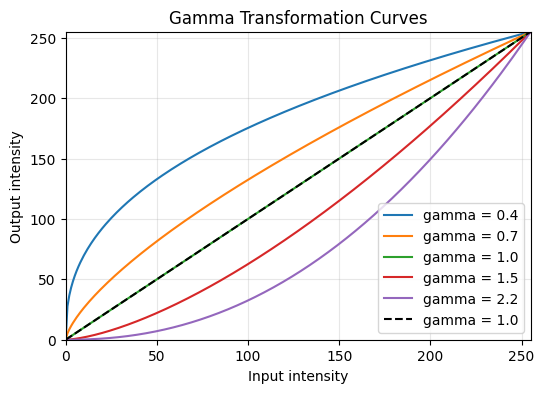

In [9]:
x = np.arange(256, dtype=np.float32)

plt.figure(figsize=(6, 4))
for gamma_value in gamma_values:
    y = 255.0 * ((x / 255.0) ** gamma_value)
    plt.plot(x, y, label=f"gamma = {gamma_value}")

plt.plot(x, x, "k--", label="gamma = 1.0")
plt.title("Gamma Transformation Curves")
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 12. Summary

Gamma correction uses the formula:

$$
s = 255 \left(\frac{r}{255}\right)^\gamma
$$

Key points:

1. `gamma < 1` brightens an image.
2. `gamma = 1` leaves an image unchanged.
3. `gamma > 1` darkens an image.
4. Vectorized NumPy code is simple and efficient.
5. A loop is useful for explanation, but not ideal for practical processing.
6. A lookup table is efficient for 8-bit images.
7. Always check whether `cv2.imread()` returns `None`.

## Review Questions

1. What happens when `gamma = 0.5`?
2. What happens when `gamma = 2.0`?
3. Why do we divide pixel values by `255.0` before applying the power-law formula?
4. Why is the lookup table method efficient for 8-bit images?